# AlgoPerf Scoring v2: Tables & Performance Profiles

Second scoring iteration for the tech report. This notebook runs **locally against
the repo's self-contained `scoring/` package**, so scores always match
`python -m scoring.score_submissions` and divide by the config's full base
workload count (9, including the never-yet-solved ImageNet ResNet).

Outputs (CSVs, plots, LaTeX tables) are written to `artifacts/leaderboard_v2/`.

Run from anywhere inside the repo:

```bash
uv run --with jupyter jupyter lab            # interactive
uv run --with jupyter,nbclient jupyter nbconvert --to notebook --execute \
  artifacts/tech_report_v2/leaderboard/score_submissions.ipynb  # headless
```

**Input format** — your submission data must follow this directory structure:
```
submission_directory/
  <submission_name>/
    <study_name>/
      <workload_name>/
        <trial_name>/
          eval_measurements.csv
```


## 1. Imports & Repo Root

Locates the repo root (so the notebook works whether launched from the root or
from this folder), then imports the scoring package.


In [59]:
import os
import pickle
import sys
from pathlib import Path

# Run everything relative to the repo root so `scoring` imports and the
# repo-relative paths in Section 2 work from any launch directory.
REPO_ROOT = next(
    p for p in [Path.cwd(), *Path.cwd().parents]
    if (p / 'scoring' / 'score_submissions.py').exists()
)
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from tabulate import tabulate

from scoring import performance_profile, scoring_utils
from scoring.config import (
    DEFAULT_TARGETS_PATH,
    SELF_TUNING_RUNTIME_FACTOR,
    WorkloadConfig,
)

## 2. Configuration

Set the paths and flags below before running the rest of the notebook.

In [60]:
# ── Required ──────────────────────────────────────────────────────────────────
# Path to the directory that contains one sub-folder per submission
# (relative to the repo root).
SUBMISSION_DIRECTORY = 'logs/self_tuning'

# Where to write output CSVs, plots, and LaTeX tables. Lives next to this
# notebook rather than in the old top-level artifacts/leaderboard_v2/ tree.
OUTPUT_DIR = 'artifacts/tech_report_v1/section_4_leaderboards/out'
# RESULTS_DIR: the notebook's explicit deliverables — LaTeX tables and plots
# that go straight into the tech report.
RESULTS_DIR = os.path.join(OUTPUT_DIR, 'results')
# BYPRODUCTS_DIR: intermediate/raw artifacts produced while computing the
# scores (score & performance-profile CSVs, time-to-target CSVs) — useful for
# debugging or reloading, but not themselves report-ready.
BYPRODUCTS_DIR = os.path.join(OUTPUT_DIR, 'byproducts')
# Per-submission summary CSVs (Section 4) are byproducts too; keep them in
# their own subfolder so they don't clutter BYPRODUCTS_DIR.
SUMMARIES_DIR = os.path.join(BYPRODUCTS_DIR, 'summaries')

# ── Submission filters (leave empty strings to include/exclude nothing) ───────
# Comma-separated names to include (empty = include all).
INCLUDE_SUBMISSIONS = ''
# Comma-separated names to exclude.
EXCLUDE_SUBMISSIONS = 'muon_torch_jax_hps,muon_torch_jax_hps_achandr,muon_torch_jax_hps_lr_fix,muon_torch_replicated_jax_hps,muon_torch_replicated_torch_hps'

# ── Scoring flags ─────────────────────────────────────────────────────────────
# Set True to enforce the competition's strict trial/study count rules.
STRICT = False
# Set True when scoring the self-tuning ruleset.
SELF_TUNING_RULESET = True
# Set True to compute and plot performance profiles after building summaries.
COMPUTE_PERFORMANCE_PROFILES = True
# Benchmark version config: base/held-out workloads, targets, step hints.
# The score divides by the number of base workloads in this config.
WORKLOAD_CONFIG = WorkloadConfig.from_json(DEFAULT_TARGETS_PATH)

# ── Performance profile parameters ────────────────────────────────────────────
MIN_TAU = 1.0
MAX_TAU = 4.0   # set None to auto-detect from data
NUM_POINTS = 100
SCALE = 'linear'  # 'linear' or 'log'

# ── Caching (optional) ────────────────────────────────────────────────────────
# Save the parsed results dict so you can reload it later without re-parsing.
SAVE_RESULTS_TO = None   # e.g. 'results.pkl'
# Load a previously saved results dict instead of re-parsing.
LOAD_RESULTS_FROM = None  # e.g. 'results.pkl'

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(SUMMARIES_DIR, exist_ok=True)  # os.makedirs also creates BYPRODUCTS_DIR

## 2b. Submission Display-Name Map
Edit the right-hand side to control how names appear in tables and plots.\nAny submission not listed here will be shown with its raw folder name.

In [61]:
# Maps raw folder names → display names used in tables, plots, and LaTeX output.
# Add or edit entries freely; unlisted names fall back to their raw folder name.
SUBMISSION_NAME_MAP = {
    'ademamix':                        'AdEMAMix (PyTorch)',
    'cautious_nadamw':                 'Cautious NAdamW (JAX)',
    'lion':                            'Lion (PyTorch)',
    'muon':                            'Muon (JAX)',
    'muon_torch':                      'Muon (PyTorch)',
    'muon_torch_jax_hps':              'Muon (PyTorch, JAX HPs)', #exclude
    'muon_torch_jax_hps_achandr':      'Muon (PyTorch, JAX HPs, achandr)', # exclude
    'muon_torch_jax_hps_lr_fix':       'Muon (PyTorch, JAX HPs, LR Fix)', # exclude
    'muon_torch_replicated_jax_hps':   'Muon (Replicated, JAX HPs)', # exclude
    'muon_torch_replicated_torch_hps': 'Muon (Replicated, Torch HPs)',
    'nadamw':                          'NAdamW (JAX)',
    'nadamw_baselinev05':              'NAdamW (Baseline AlgoPerf v0.5) (JAX)',
    'nadamw_resnet':                   'NAdamW (Tuned for ResNet) (JAX)',
    'schedule_free_adamw':             'Schedule-Free AdamW (PyTorch)',
    'schedule_free_adamw_jax':         'Schedule-Free AdamW (JAX)',
    'schedule_free_adamw_jax_v2':      'Schedule-Free AdamW v2 (JAX)',
    'schedule_free_adamw_v2':          'Schedule-Free AdamW v2 (PyTorch)',
    'single_worker_diloco':            'Single Worker DiLoCo (JAX)',
    'single_worker_dilocov2':          'Single Worker DiLoCo v2 (JAX)',
}

def pretty(name):
    """Return the display name for a submission, falling back to the raw name."""
    return SUBMISSION_NAME_MAP.get(name, name)

_PRETTY_TO_RAW = {v: k for k, v in SUBMISSION_NAME_MAP.items()}

# Maps raw folder names → LaTeX \newcommand macros defined in the tech report
# (e.g. \newcommand{\sfadamw}{\textsc{Schedule-Free AdamW}\xspace}). Used only
# when rendering LaTeX tables (see `latex_name()` below); submissions without
# a defined macro fall back to their pretty display name.
SUBMISSION_LATEX_MACRO = {
    'ademamix':                   r'\ademamix',
    'cautious_nadamw':            r'\cautiousnadamw',
    'lion':                       r'\lion',
    'muon':                       r'\muonjax',
    'muon_torch':                 r'\muonpt',
    'nadamw':                     r'\nadamw',
    'nadamw_baselinev05':         r'\nadamwbase',
    'nadamw_resnet':              r'\nadamwresnet',
    'schedule_free_adamw':        r'\sfadamw',
    'schedule_free_adamw_jax':    r'\sfadamwjax',
    'schedule_free_adamw_jax_v2': r'\sfadamwjaxii',
    'schedule_free_adamw_v2':     r'\sfadamwii',
    'single_worker_diloco':       r'\dilocosw',
    'single_worker_dilocov2':     r'\dilocoswii',
}

def latex_name(name):
    """Return the LaTeX macro for a submission, given its pretty display
    name (as used in the DataFrame indices built in Section 4). Falls back
    to the pretty name itself if no macro is defined."""
    raw = _PRETTY_TO_RAW.get(name, name)
    return SUBMISSION_LATEX_MACRO.get(raw, name)

## 3. Helpers: Submission Summary & Leaderboard Score

Imported directly from `scoring/score_submissions.py` so the notebook can never
drift from the official pipeline.


In [62]:
from scoring.score_submissions import (
    compute_leaderboard_score,
    get_submission_summary as _get_submission_summary,
)


def get_submission_summary(df):
    """Canonical per-workload summary, bound to this notebook's config."""
    return _get_submission_summary(df, WORKLOAD_CONFIG)



## 3b. Plot Theme

Sets a publication-quality matplotlib style and defines `plot_performance_profiles_styled`.\nWith 19 submissions the plot cycles through 10 colorblind-safe colors × 4 line styles so it stays readable in greyscale and print.

In [63]:
import itertools
import math
import matplotlib as mpl

# ── Colorblind-safe 10-color palette (Paul Tol "bright") ──────────────────────
_COLORS = [
    '#4477AA',  # blue
    '#EE6677',  # red
    '#228833',  # green
    '#CCBB44',  # yellow
    '#66CCEE',  # cyan
    '#AA3377',  # purple
    '#BBBBBB',  # grey
    '#EE7733',  # orange
    '#009988',  # teal
    '#CC3311',  # vermillion
]
_LINE_STYLES = ['-', '--', '-.', ':']

# 10 solid lines, then 9 dashed, etc. — enough for 19 submissions.
_STYLE_CYCLE = list(itertools.islice(
    ((c, ls) for ls in _LINE_STYLES for c in _COLORS),
    40,
))

# ── rcParams: tuned for a two-column tech-report (e.g. NeurIPS / ICML) ────────
mpl.rcParams.update({
    'figure.figsize':        (9, 4.5),
    'figure.dpi':            150,
    'savefig.dpi':           300,
    'savefig.bbox':          'tight',
    'savefig.pad_inches':    0.05,
    'font.family':           'serif',
    'font.serif':            ['Times New Roman', 'DejaVu Serif'],
    'font.size':             11,
    'axes.titlesize':        11,
    'axes.labelsize':        11,
    'xtick.labelsize':       10,
    'ytick.labelsize':       10,
    'legend.fontsize':       8.5,
    'legend.title_fontsize': 9,
    'legend.framealpha':     0.92,
    'legend.edgecolor':      '#cccccc',
    'legend.borderpad':      0.5,
    'legend.labelspacing':   0.35,
    'axes.grid':             True,
    'grid.alpha':            0.3,
    'grid.linestyle':        '--',
    'grid.linewidth':        0.6,
    'axes.spines.top':       False,
    'axes.spines.right':     False,
    'axes.linewidth':        0.8,
    'lines.linewidth':       1.6,
})


def plot_performance_profiles_styled(
    perf_df,
    df_col,
    scale='linear',
    save_dir=None,
    figsize=(9, 5.5),
    title=None,
):
    """
    Publication-quality performance profile plot for a tech report.

    Each submission's (color, line-style) pair comes from the shared
    SUBMISSION_STYLE registry (built in Section 4, once `results` is known),
    so a submission always gets the same color in every figure in this
    notebook — performance profiles and the Section 6 scatter plots alike.
    Colors remain legible in greyscale and for colorblind readers.
    The legend is placed below the plot.
    Saves both a vector PDF and a 300-dpi PNG.
    """
    fig, ax = plt.subplots(figsize=figsize)

    for submission in perf_df.index:
        style = SUBMISSION_STYLE.get(submission, {'color': '#333333', 'linestyle': '-'})
        ax.plot(
            perf_df.columns,
            perf_df.loc[submission],
            label=submission,
            color=style['color'],
            linestyle=style['linestyle'],
            linewidth=1.6,
            alpha=0.92,
        )

    ax.set_xlabel('Performance ratio τ  (relative to best submission)')
    ax.set_ylabel('Fraction of workloads solved ρ(τ)')
    ax.set_xlim(perf_df.columns.min(), perf_df.columns.max())
    ax.set_ylim(-0.02, 1.05)
    ax.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(xmax=1, decimals=0))

    if title:
        ax.set_title(title, pad=8)

    # ── Legend below the axes ──────────────────────────────────────────────────
    n = len(perf_df.index)
    ncol = max(3, math.ceil(n / 4))   # ~4 rows for any submission count
    ax.legend(
        loc='upper center',
        bbox_to_anchor=(0.5, -0.22),
        ncol=ncol,
        borderaxespad=0,
        frameon=True,
        handlelength=2.0,
        handleheight=0.9,
        columnspacing=1.0,
        labelspacing=0.35,
    )

    # Reserve vertical space proportional to the number of legend rows so the
    # legend never overlaps the x-axis label. The legend is anchored 0.22
    # axes-heights below the axes (above); the fixed +40pt buffer covers the
    # x-axis ticks, tick labels, and axis label that sit in that same gap.
    n_rows = math.ceil(n / ncol)
    pts_per_row = mpl.rcParams['legend.fontsize'] * 1.55
    fig_height_pts = figsize[1] * 72
    legend_frac = (n_rows * pts_per_row + 40) / fig_height_pts
    fig.subplots_adjust(
        left=0.07,
        right=0.98,
        top=0.91 if title else 0.97,
        bottom=min(0.14 + legend_frac, 0.58),
    )

    if save_dir:
        base = os.path.join(save_dir, f'performance_profile_by_{df_col}')
        fig.savefig(f'{base}.pdf', format='pdf')
        fig.savefig(f'{base}.png', format='png', dpi=300)
        print(f'Saved → {base}.pdf / .png')

    return fig, ax

## 4. Load & Summarize Submissions

In [64]:
results = {}

_exclude     = {s.strip() for s in EXCLUDE_SUBMISSIONS.split(',')} - {''}
_include_raw = {s.strip() for s in INCLUDE_SUBMISSIONS.split(',')} - {''}

print(f'Excluding ({len(_exclude)}): {sorted(_exclude) or "(none)"}')
print(f'Including ({len(_include_raw)}): {sorted(_include_raw) or "(all)"}')

def _is_included(raw_name):
    if raw_name in _exclude:
        return False
    if _include_raw and raw_name not in _include_raw:
        return False
    return True

if LOAD_RESULTS_FROM:
    load_path = os.path.join(OUTPUT_DIR, LOAD_RESULTS_FROM)
    print(f'\nLoading cached results from {load_path}')
    with open(load_path, 'rb') as f:
        cached = pickle.load(f)
    _pretty_to_raw = {v: k for k, v in SUBMISSION_NAME_MAP.items()}
    for name, df in cached.items():
        raw = _pretty_to_raw.get(name, name)
        if _is_included(raw):
            results[name] = df
            print(f'  ✓ {name}')
        else:
            print(f'  ✗ {name}  ← excluded')
else:
    all_submission_dirs = sorted(os.listdir(SUBMISSION_DIRECTORY))
    print(f'\nFound {len(all_submission_dirs)} folders:')
    for s in all_submission_dirs:
        tag = '✓' if _is_included(s) else '✗  ← excluded'
        print(f'  {tag} {s}')
    print()

    for submission in all_submission_dirs:
        if not _is_included(submission):
            continue
        print(f'\n=== {pretty(submission)} ({submission}) ===')
        experiment_path = os.path.join(SUBMISSION_DIRECTORY, submission)
        df = scoring_utils.get_experiment_df(experiment_path)
        results[pretty(submission)] = df

        summary_df = get_submission_summary(df)
        summary_df.to_csv(os.path.join(SUMMARIES_DIR, f'{submission}_summary.csv'))
        # display(summary_df)

    if SAVE_RESULTS_TO:
        save_path = os.path.join(OUTPUT_DIR, SAVE_RESULTS_TO)
        with open(save_path, 'wb') as f:
            pickle.dump(results, f)
        print(f'Results cached to {save_path}')

print(f'\nLoaded {len(results)} submission(s): {list(results.keys())}')

# ── Shared color/linestyle per submission ──────────────────────────────────
# Assigned once, from a fixed alphabetical order, so every figure in this
# notebook (performance profiles in Sections 5-7, scatter plots in Section 6)
# uses the same color for the same submission.
SUBMISSION_STYLE = {
    name: {'color': color, 'linestyle': linestyle}
    for name, (color, linestyle) in zip(sorted(results.keys()), _STYLE_CYCLE)
}

Excluding (5): ['muon_torch_jax_hps', 'muon_torch_jax_hps_achandr', 'muon_torch_jax_hps_lr_fix', 'muon_torch_replicated_jax_hps', 'muon_torch_replicated_torch_hps']
Including (0): (all)

Found 19 folders:
  ✓ ademamix
  ✓ cautious_nadamw
  ✓ lion
  ✓ muon
  ✓ muon_torch
  ✗  ← excluded muon_torch_jax_hps
  ✗  ← excluded muon_torch_jax_hps_achandr
  ✗  ← excluded muon_torch_jax_hps_lr_fix
  ✗  ← excluded muon_torch_replicated_jax_hps
  ✗  ← excluded muon_torch_replicated_torch_hps
  ✓ nadamw
  ✓ nadamw_baselinev05
  ✓ nadamw_resnet
  ✓ schedule_free_adamw
  ✓ schedule_free_adamw_jax
  ✓ schedule_free_adamw_jax_v2
  ✓ schedule_free_adamw_v2
  ✓ single_worker_diloco
  ✓ single_worker_dilocov2


=== AdEMAMix (PyTorch) (ademamix) ===
['imagenet_resnet_pytorch', 'fastmri_pytorch', 'imagenet_vit_pytorch', 'librispeech_conformer_pytorch', 'ogbg_pytorch', 'librispeech_deepspeech_pytorch', 'wmt_pytorch', 'criteo1tb_pytorch', 'finewebedu_lm_pytorch']
['imagenet_resnet_pytorch', 'fastmri_pytorch',

## 5. Performance Profiles, Leaderboard Scores & LaTeX Table

Saved → artifacts/tech_report_v1/section_4_leaderboards/out/results/performance_profile_by_score.pdf / .png


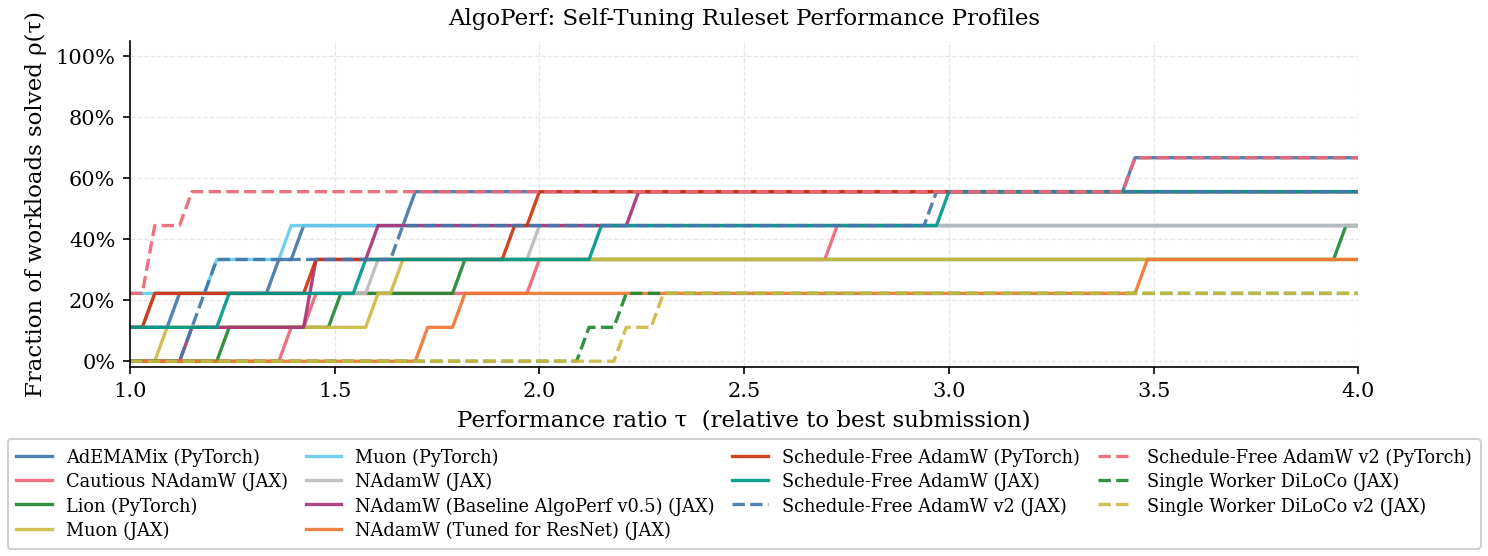


--- Leaderboard Scores ---


,score
submission,
Schedule-Free AdamW v2 (PyTorch),0.567901
AdEMAMix (PyTorch),0.519080
Schedule-Free AdamW (PyTorch),0.466891
NAdamW (Baseline AlgoPerf v0.5) (JAX),0.450617
Schedule-Free AdamW v2 (JAX),0.440516
Muon (PyTorch),0.423120
Schedule-Free AdamW (JAX),0.410774
NAdamW (JAX),0.384400
Cautious NAdamW (JAX),0.314254


Saved to artifacts/tech_report_v1/section_4_leaderboards/out/byproducts/scores.csv
\begin{table}[h]
  \centering
  \caption{AlgoPerf Self-Tuning Leaderboard}
  \label{tab:scores}
  \begin{tabular}{rlr}
    \toprule
    Rank & Submission & Score \\
    \midrule
    1 & \sfadamwii & \textbf{0.5679} \\
    2 & \ademamix & 0.5191 \\
    3 & \sfadamw & 0.4669 \\
    4 & \nadamwbase & 0.4506 \\
    5 & \sfadamwjaxii & 0.4405 \\
    6 & \muonpt & 0.4231 \\
    7 & \sfadamwjax & 0.4108 \\
    8 & \nadamw & 0.3844 \\
    9 & \cautiousnadamw & 0.3143 \\
    10 & \muonjax & 0.2845 \\
    11 & \lion & 0.2783 \\
    12 & \nadamwresnet & 0.1857 \\
    13 & \dilocosw & 0.1369 \\
    14 & \dilocoswii & 0.1302 \\
    \bottomrule
  \end{tabular}
\end{table}

Saved to artifacts/tech_report_v1/section_4_leaderboards/out/results/scores_table.tex


In [65]:
if not STRICT:
    print(
        'WARNING: STRICT=False relaxes criteria on held-out workloads, '
        'trial counts, and study counts. Scores may not match official '
        'competition scoring. Set STRICT=True to enforce all rules.'
    )

if COMPUTE_PERFORMANCE_PROFILES:
    performance_profile_df = performance_profile.compute_performance_profiles(
        results,
        WORKLOAD_CONFIG,
        time_col='score',
        min_tau=MIN_TAU,
        max_tau=MAX_TAU,
        reference_submission_tag=None,
        num_points=NUM_POINTS,
        scale=SCALE,
        verbosity=0,
        self_tuning_ruleset=SELF_TUNING_RULESET,
        strict=STRICT,
        output_dir=BYPRODUCTS_DIR,
    )

    # Save profile CSV for reuse without re-running the full pipeline.
    profile_csv = os.path.join(BYPRODUCTS_DIR, 'performance_profile_score.csv')
    performance_profile_df.to_csv(profile_csv)

    # ── Styled plot ────────────────────────────────────────────────────────────
    fig, ax = plot_performance_profiles_styled(
        performance_profile_df,
        'score',
        scale=SCALE,
        save_dir=RESULTS_DIR,
        title='AlgoPerf: Self-Tuning Ruleset Performance Profiles',
    )
    plt.show()

    # ── Scores table ──────────────────────────────────────────────────────────
    scores = compute_leaderboard_score(performance_profile_df)
    scores_path = os.path.join(BYPRODUCTS_DIR, 'scores.csv')
    scores.to_csv(scores_path)

    print('\n--- Leaderboard Scores ---')
    display(scores.sort_values('score', ascending=False))
    print(f'Saved to {scores_path}')

    # ── LaTeX table ────────────────────────────────────────────────────────────
    def scores_to_latex(scores_df, caption='AlgoPerf Self-Tuning Leaderboard', label='tab:scores'):
        """
        Render a leaderboard scores DataFrame as a LaTeX table.
        Submission names come from the DataFrame index (pretty-named), rendered
        via their `latex_name()` \\newcommand macro.
        Scores are formatted to 4 decimal places; best score is bolded.
        """
        df = scores_df.sort_values('score', ascending=False).copy()
        df['rank'] = range(1, len(df) + 1)

        best_score = df['score'].iloc[0]

        rows = []
        for rank, (name, row) in enumerate(df.iterrows(), start=1):
            score_str = f'{row["score"]:.4f}'
            if row['score'] == best_score:
                score_str = r'\textbf{' + score_str + '}'
            rows.append(f'    {rank} & {latex_name(name)} & {score_str} \\\\')

        body = '\n'.join(rows)

        latex = (
            r'\begin{table}[h]' + '\n'
            r'  \centering' + '\n'
            r'  \caption{' + caption + '}\n'
            r'  \label{' + label + '}\n'
            r'  \begin{tabular}{rlr}' + '\n'
            r'    \toprule' + '\n'
            r'    Rank & Submission & Score \\' + '\n'
            r'    \midrule' + '\n'
            + body + '\n'
            r'    \bottomrule' + '\n'
            r'  \end{tabular}' + '\n'
            r'\end{table}'
        )
        return latex


    latex_table = scores_to_latex(scores)
    print(latex_table)

    latex_path = os.path.join(RESULTS_DIR, 'scores_table.tex')
    with open(latex_path, 'w') as f:
        f.write(latex_table)
    print(f'\nSaved to {latex_path}')

## 5b. Time-to-Target Table
Shows the median time each submission took to reach the validation target on each workload, as a fraction of that workload's maximum allowed runtime.\n`inf` means the target was not reached within the run.

In [66]:
ttt = pd.read_csv(os.path.join(BYPRODUCTS_DIR, 'time_to_targets.csv'), index_col=0)

# ── Per-workload max time budget ───────────────────────────────────────────────
# `max_allowed_runtime_sec` comes straight from WORKLOAD_CONFIG (i.e.
# scoring/workload_targets.json), which vendors each base workload's
# `algoperf/workloads/<workload>/workload.py` value. WorkloadConfig applies
# the self-tuning ruleset's SELF_TUNING_RUNTIME_FACTOR (1.5x) internally.
# Format: finite values as a fraction (2 decimals) of the workload's time
# budget, inf as em-dash.
def _fmt(workload, v):
    if pd.isna(v) or v == float('inf'):
        return r'\textemdash{}'
    budget = WORKLOAD_CONFIG.max_runtime_sec(
        workload, self_tuning_ruleset=SELF_TUNING_RULESET
    )
    return f'{v / budget:.2f}'

ttt_display = ttt.apply(lambda col: col.map(lambda v: _fmt(col.name, v)))
ttt_display.index.name = 'Submission'
# Order rows by wall-clock leaderboard score (best first), matching Section 5.
ttt_display = ttt_display.loc[scores.sort_values('score', ascending=False).index]

print('--- Time to Target (fraction of max runtime budget) ---')
display(ttt_display)

# ── Workload column → LaTeX macro ─────────────────────────────────────────────
_WL_MACRO = {
    'criteo1tb':              r'\criteo',
    'fastmri':                r'\fastmri',
    'finewebedu_lm':          r'\finewebedu',
    'imagenet_resnet':        r'\resnet',
    'imagenet_vit':           r'\vit',
    'librispeech_conformer':  r'\conformer',
    'librispeech_deepspeech': r'\deepspeech',
    'ogbg':                   r'\ogbg',
    'wmt':                    r'\wmt',
}

workloads  = list(ttt.columns)
col_spec   = 'l' + 'r' * len(workloads)
wl_headers = ' & '.join(_WL_MACRO.get(w, w) for w in workloads)

rows = []
for name, row in ttt_display.iterrows():
    # % is a LaTeX comment character; escape it so a value like "34%"
    # doesn't swallow the rest of the row.
    cells = [str(v).replace('%', r'\%') for v in row]
    rows.append('      ' + latex_name(name) + ' & ' + ' & '.join(cells) + r' \\')

_budget_caption = (
    r"Time to target as a fraction of each workload's self-tuning-ruleset "
    rf'time budget ({SELF_TUNING_RUNTIME_FACTOR:g}\times the external-tuning maximum allowed runtime).'
    if SELF_TUNING_RULESET else
    r"Time to target as a fraction of each workload's maximum allowed runtime."
)

latex = '\n'.join([
    r'\begin{table}[htbp]',
    r'  \centering',
    r'  \caption{' + _budget_caption + r' \textemdash{} = target not reached.}',
    r'  \label{tab:time_to_target}',
    r'  \resizebox{\textwidth}{!}{%',
    r'  \begin{tabular}{' + col_spec + '}',
    r'    \toprule',
    r'    Submission & ' + wl_headers + r' \\',
    r'    \midrule',
    *rows,
    r'    \bottomrule',
    r'  \end{tabular}%',
    r'  }',
    r'\end{table}',
])

ttt_latex_path = os.path.join(RESULTS_DIR, 'time_to_target_table.tex')
with open(ttt_latex_path, 'w') as f:
    f.write(latex)
print(f'\nLaTeX saved → {ttt_latex_path}')

--- Time to Target (fraction of max runtime budget) ---


,criteo1tb,fastmri,finewebedu_lm,imagenet_resnet,imagenet_vit,librispeech_conformer,librispeech_deepspeech,ogbg,wmt
submission,,,,,,,,,
Schedule-Free AdamW v2 (PyTorch),0.56,0.27,\textemdash{},\textemdash{},\textemdash{},0.85,0.76,0.37,0.43
AdEMAMix (PyTorch),0.59,0.37,0.38,\textemdash{},\textemdash{},0.75,\textemdash{},0.37,0.72
Schedule-Free AdamW (PyTorch),0.77,0.29,\textemdash{},\textemdash{},\textemdash{},\textemdash{},0.73,0.21,0.83
NAdamW (Baseline AlgoPerf v0.5) (JAX),0.61,0.39,0.43,\textemdash{},\textemdash{},\textemdash{},\textemdash{},0.24,0.62
Schedule-Free AdamW v2 (JAX),0.61,0.45,0.32,\textemdash{},0.88,\textemdash{},\textemdash{},0.32,\textemdash{}
Muon (PyTorch),0.53,\textemdash{},0.32,\textemdash{},\textemdash{},\textemdash{},\textemdash{},0.11,0.59
Schedule-Free AdamW (JAX),\textemdash{},0.58,0.27,\textemdash{},0.91,\textemdash{},\textemdash{},0.32,0.67
NAdamW (JAX),0.56,0.44,0.54,\textemdash{},0.75,\textemdash{},\textemdash{},\textemdash{},\textemdash{}
Cautious NAdamW (JAX),\textemdash{},0.39,0.54,\textemdash{},\textemdash{},\textemdash{},\textemdash{},0.29,0.59



LaTeX saved → artifacts/tech_report_v1/section_4_leaderboards/out/results/time_to_target_table.tex


## 6. Step-Based Scoring: Step vs. Wall-Clock Efficiency

Re-scores every submission with the identical performance-profile machinery,
but using `global_step` (optimizer steps to target) as the time column instead
of wall-clock seconds. Same workload config, same $\tau$ range, same
denominator. Artifacts are written with a `_steps` suffix, plus:

- `steps_to_target_table.tex` — per-workload median steps to target
- `scores_steps_table.tex` — step-based leaderboard ranking
- `scores_comparison_time_vs_steps.tex` — wall-clock vs. step-based scores
  and ranks, plus the per-submission rank shift ($\Delta$) between the two
- `wallclock_vs_steps.{pdf,png}` — scatter of the two benchmark scores

Caveat: submissions choose their own batch sizes, so step counts compare
optimizer updates, not examples seen; steps are not sample-normalized.


Saved → artifacts/tech_report_v1/section_4_leaderboards/out/results/performance_profile_by_global_step.pdf / .png


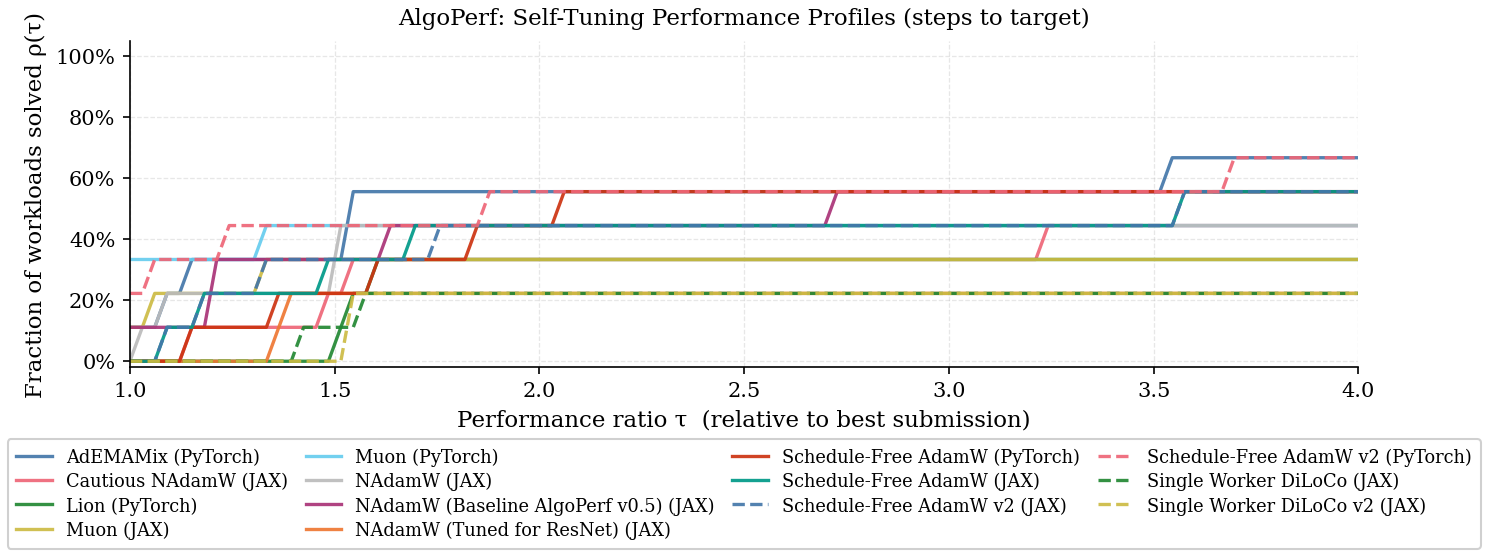

--- Step-based Leaderboard Scores ---


,score
submission,
AdEMAMix (PyTorch),0.525814
Schedule-Free AdamW v2 (PyTorch),0.525253
NAdamW (Baseline AlgoPerf v0.5) (JAX),0.454545
Schedule-Free AdamW (PyTorch),0.446128
Muon (PyTorch),0.432660
Schedule-Free AdamW v2 (JAX),0.412458
Schedule-Free AdamW (JAX),0.409091
NAdamW (JAX),0.404040
Cautious NAdamW (JAX),0.319865


\begin{table}[h]
  \centering
  \caption{AlgoPerf Self-Tuning Leaderboard (steps to target)}
  \label{tab:scores_steps}
  \begin{tabular}{rlr}
    \toprule
    Rank & Submission & Score \\
    \midrule
    1 & \ademamix & \textbf{0.5258} \\
    2 & \sfadamwii & 0.5253 \\
    3 & \nadamwbase & 0.4545 \\
    4 & \sfadamw & 0.4461 \\
    5 & \muonpt & 0.4327 \\
    6 & \sfadamwjaxii & 0.4125 \\
    7 & \sfadamwjax & 0.4091 \\
    8 & \nadamw & 0.4040 \\
    9 & \cautiousnadamw & 0.3199 \\
    10 & \muonjax & 0.3199 \\
    11 & \lion & 0.2733 \\
    12 & \nadamwresnet & 0.1953 \\
    13 & \dilocosw & 0.1863 \\
    14 & \dilocoswii & 0.1829 \\
    \bottomrule
  \end{tabular}
\end{table}

Saved to artifacts/tech_report_v1/section_4_leaderboards/out/results/scores_steps_table.tex


In [67]:
# ── Step-based performance profiles and leaderboard scores ────────────────────
performance_profile_steps_df = performance_profile.compute_performance_profiles(
    results,
    WORKLOAD_CONFIG,
    time_col='global_step',
    min_tau=MIN_TAU,
    max_tau=MAX_TAU,
    reference_submission_tag=None,
    num_points=NUM_POINTS,
    scale=SCALE,
    verbosity=0,
    self_tuning_ruleset=SELF_TUNING_RULESET,
    strict=STRICT,
    output_dir=BYPRODUCTS_DIR,          # writes time_to_targets_steps.csv
    artifact_suffix='_steps',
)
performance_profile_steps_df.to_csv(
    os.path.join(BYPRODUCTS_DIR, 'performance_profile_global_step.csv')
)

fig, ax = plot_performance_profiles_styled(
    performance_profile_steps_df,
    'global_step',
    scale=SCALE,
    save_dir=RESULTS_DIR,
    title='AlgoPerf: Self-Tuning Performance Profiles (steps to target)',
)
plt.show()

scores_steps = compute_leaderboard_score(performance_profile_steps_df)
scores_steps.to_csv(os.path.join(BYPRODUCTS_DIR, 'scores_steps.csv'))
print('--- Step-based Leaderboard Scores ---')
display(scores_steps.sort_values('score', ascending=False))

# ── LaTeX table ────────────────────────────────────────────────────────────
scores_steps_latex = scores_to_latex(
    scores_steps,
    caption='AlgoPerf Self-Tuning Leaderboard (steps to target)',
    label='tab:scores_steps',
)
print(scores_steps_latex)

scores_steps_latex_path = os.path.join(RESULTS_DIR, 'scores_steps_table.tex')
with open(scores_steps_latex_path, 'w') as f:
    f.write(scores_steps_latex)
print(f'\nSaved to {scores_steps_latex_path}')

In [68]:
# ── Wall-clock vs. step-based leaderboard comparison ──────────────────────────
# Both use the same performance-profile scoring; only the notion of training
# time differs (seconds vs. optimizer steps to target). rank_shift captures
# how much a submission's rank changes between the two.
cmp = pd.DataFrame({
    'wallclock': scores['score'],
    'steps': scores_steps['score'],
})
cmp['rank_wallclock'] = cmp.wallclock.rank(ascending=False, method='min').astype(int)
cmp['rank_steps']     = cmp.steps.rank(ascending=False, method='min').astype(int)
cmp['rank_shift']     = cmp.rank_wallclock - cmp.rank_steps
cmp = cmp.sort_values('wallclock', ascending=False)

cmp_csv_path = os.path.join(BYPRODUCTS_DIR, 'scores_wallclock_vs_steps.csv')
cmp.to_csv(cmp_csv_path)
print(f'--- Wall-clock vs. Step-based Leaderboard Comparison ---')
display(cmp.round(4))
print(f'Saved to {cmp_csv_path}')

def _fmt_shift(d):
    if d > 0:
        return rf'$\uparrow${d}'
    if d < 0:
        return rf'$\downarrow${-d}'
    return '--'

_best_wall  = cmp.wallclock.max()
_best_steps = cmp.steps.max()
_cmp_rows = []
for name, row in cmp.iterrows():
    wall  = f'{row.wallclock:.4f}'
    steps = f'{row.steps:.4f}'
    if row.wallclock == _best_wall:
        wall = r'\textbf{' + wall + '}'
    if row.steps == _best_steps:
        steps = r'\textbf{' + steps + '}'
    _cmp_rows.append(
        f'    {latex_name(name)} & {wall} & {int(row.rank_wallclock)} & {steps} & '
        f'{int(row.rank_steps)} & {_fmt_shift(int(row.rank_shift))} ' + r'\\'
    )

cmp_latex = '\n'.join([
    r'\begin{table}[htbp]',
    r'  \centering',
    r'  \caption{Wall-clock vs.\ step-based benchmark scores. Both use the same'
    r' performance-profile scoring; only the notion of training time differs'
    r' (seconds vs.\ optimizer steps to target). $\Delta$ is the rank change'
    r' when moving from wall-clock to step-based scoring.}',
    r'  \label{tab:leaderboard_steps}',
    r'  \begin{tabular}{lrrrrc}',
    r'    \toprule',
    r'    & \multicolumn{2}{c}{Wall-clock} & \multicolumn{2}{c}{Steps} & \\',
    r'    \cmidrule(lr){2-3}\cmidrule(lr){4-5}',
    r'    Submission & Score & Rank & Score & Rank & $\Delta$ \\',
    r'    \midrule',
    *_cmp_rows,
    r'    \bottomrule',
    r'  \end{tabular}',
    r'\end{table}',
])

leaderboard_steps_latex_path = os.path.join(RESULTS_DIR, 'scores_comparison_time_vs_steps.tex')
with open(leaderboard_steps_latex_path, 'w') as f:
    f.write(cmp_latex)
print(f'\nSaved to {leaderboard_steps_latex_path}')

--- Wall-clock vs. Step-based Leaderboard Comparison ---


,wallclock,steps,rank_wallclock,rank_steps,rank_shift
submission,,,,,
Schedule-Free AdamW v2 (PyTorch),0.5679,0.5253,1,2,-1
AdEMAMix (PyTorch),0.5191,0.5258,2,1,1
Schedule-Free AdamW (PyTorch),0.4669,0.4461,3,4,-1
NAdamW (Baseline AlgoPerf v0.5) (JAX),0.4506,0.4545,4,3,1
Schedule-Free AdamW v2 (JAX),0.4405,0.4125,5,6,-1
Muon (PyTorch),0.4231,0.4327,6,5,1
Schedule-Free AdamW (JAX),0.4108,0.4091,7,7,0
NAdamW (JAX),0.3844,0.4040,8,8,0
Cautious NAdamW (JAX),0.3143,0.3199,9,9,0


Saved to artifacts/tech_report_v1/section_4_leaderboards/out/byproducts/scores_wallclock_vs_steps.csv

Saved to artifacts/tech_report_v1/section_4_leaderboards/out/results/scores_comparison_time_vs_steps.tex


In [69]:
# ── Steps-to-target table (analog of the time-to-target table) ────────────────
stt = pd.read_csv(os.path.join(BYPRODUCTS_DIR, 'time_to_targets_steps.csv'), index_col=0)

def _fmt_steps(v):
    if pd.isna(v) or v == float('inf'):
        return r'\textemdash{}'
    return f'{v:,.0f}'

stt_display = stt.map(_fmt_steps)
stt_display.index.name = 'Submission'
# Order rows by step-based leaderboard score (best first), matching this
# section's own leaderboard above.
stt_display = stt_display.loc[scores_steps.sort_values('score', ascending=False).index]
display(stt_display)

_stt_workloads = list(stt.columns)
_stt_col_spec  = 'l' + 'r' * len(_stt_workloads)
_stt_headers   = ' & '.join(_WL_MACRO.get(w, w) for w in _stt_workloads)

_stt_rows = []
for name, row in stt_display.iterrows():
    _stt_rows.append('      ' + latex_name(name) + ' & ' + ' & '.join(str(v) for v in row) + r' \\')

stt_latex = '\n'.join([
    r'\begin{table}[htbp]',
    r'  \centering',
    r'  \caption{Median number of optimizer steps to reach the validation target.'
    r' \textemdash{} = target not reached. Submissions choose their own batch'
    r' sizes, so step counts compare optimizer updates, not examples seen.}',
    r'  \label{tab:steps_to_target}',
    r'  \resizebox{\textwidth}{!}{%',
    r'  \begin{tabular}{' + _stt_col_spec + '}',
    r'    \toprule',
    r'    Submission & ' + _stt_headers + r' \\',
    r'    \midrule',
    *_stt_rows,
    r'    \bottomrule',
    r'  \end{tabular}%',
    r'  }',
    r'\end{table}',
])

with open(os.path.join(RESULTS_DIR, 'steps_to_target_table.tex'), 'w') as f:
    f.write(stt_latex)
print('LaTeX saved -> steps_to_target_table.tex')

,criteo1tb,fastmri,finewebedu_lm,imagenet_resnet,imagenet_vit,librispeech_conformer,librispeech_deepspeech,ogbg,wmt
submission,,,,,,,,,
AdEMAMix (PyTorch),"8,371","10,206","44,503",\textemdash{},\textemdash{},"67,706",\textemdash{},"27,247","112,742"
Schedule-Free AdamW v2 (PyTorch),"7,951","12,431",\textemdash{},\textemdash{},\textemdash{},"83,184","78,669","28,449","73,222"
NAdamW (Baseline AlgoPerf v0.5) (JAX),"9,145","6,648","47,039",\textemdash{},\textemdash{},\textemdash{},\textemdash{},"20,879","118,600"
Schedule-Free AdamW (PyTorch),"10,346","10,599",\textemdash{},\textemdash{},\textemdash{},\textemdash{},"90,588","15,853","133,517"
Muon (PyTorch),"7,716",\textemdash{},"39,220",\textemdash{},\textemdash{},\textemdash{},\textemdash{},"7,711","97,224"
Schedule-Free AdamW v2 (JAX),"9,005","8,750","68,640",\textemdash{},"164,206",\textemdash{},\textemdash{},"27,457",\textemdash{}
Schedule-Free AdamW (JAX),\textemdash{},"7,160","57,242",\textemdash{},"175,889",\textemdash{},\textemdash{},"27,341","122,198"
NAdamW (JAX),"8,286","9,924","58,784",\textemdash{},"152,461",\textemdash{},\textemdash{},\textemdash{},\textemdash{}
Cautious NAdamW (JAX),\textemdash{},"7,518","58,199",\textemdash{},\textemdash{},\textemdash{},\textemdash{},"24,948","112,372"


LaTeX saved -> steps_to_target_table.tex


Saved -> wallclock_vs_steps.pdf / .png


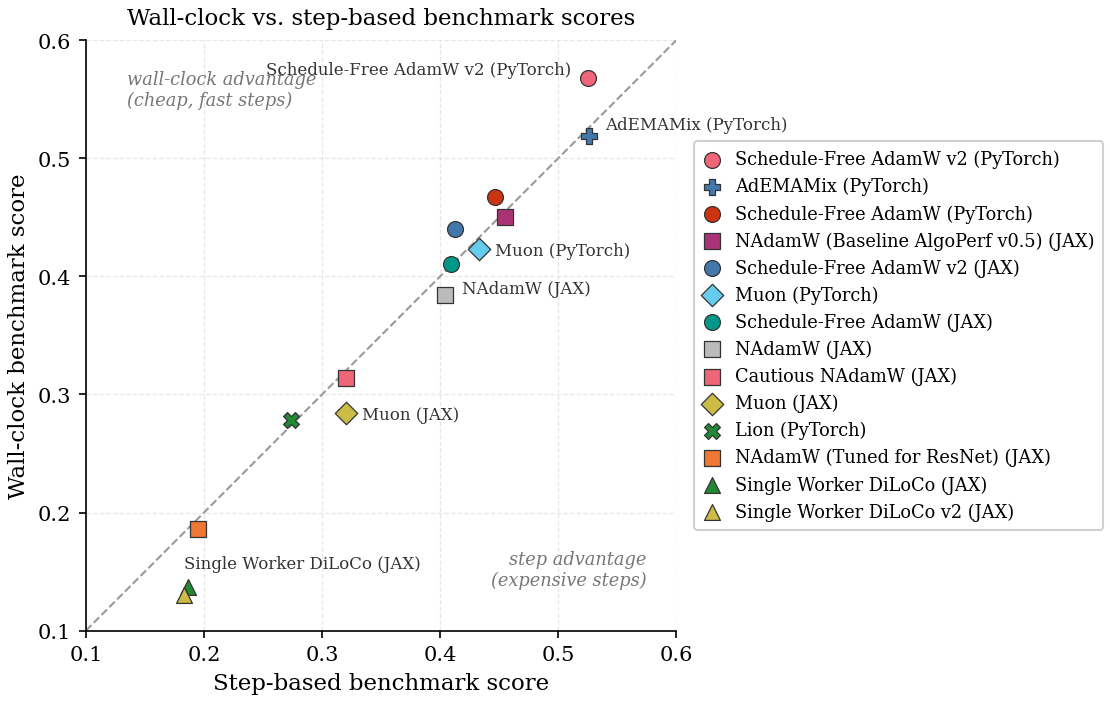

In [70]:
# ── Scatter: wall-clock score vs. step-based score ────────────────────────────
# Reuses `cmp` (built above for the wall-clock-vs-steps comparison table).
# Color comes from the shared SUBMISSION_STYLE registry (matches the
# performance-profile plots); marker shape is one shape per algorithm family
# (_FAMILIES), so points from the same algorithm are visually grouped even
# before reading the legend. Dark marker edges keep light fills legible on
# white.
_FAMILIES = [
    ('o', ['Schedule-Free AdamW v2 (PyTorch)', 'Schedule-Free AdamW v2 (JAX)',
           'Schedule-Free AdamW (JAX)', 'Schedule-Free AdamW (PyTorch)']),
    ('s', ['NAdamW (JAX)', 'NAdamW (Baseline AlgoPerf v0.5) (JAX)',
           'NAdamW (Tuned for ResNet) (JAX)', 'Cautious NAdamW (JAX)']),
    ('D', ['Muon (PyTorch)', 'Muon (JAX)']),
    ('^', ['Single Worker DiLoCo (JAX)', 'Single Worker DiLoCo v2 (JAX)']),
    ('P', ['AdEMAMix (PyTorch)']),
    ('X', ['Lion (PyTorch)']),
]
_FAMILY_MARKER = {name: marker for marker, members in _FAMILIES for name in members}

fig, ax = plt.subplots(figsize=(9.5, 5.6))

lims = (0.10, 0.60)
ax.plot(lims, lims, linestyle='--', color='#999999', linewidth=1.0, zorder=1)
ax.text(0.135, 0.575, 'wall-clock advantage\n(cheap, fast steps)',
        ha='left', va='top', fontsize=8.5, style='italic', color='#777777')
ax.text(0.575, 0.135, 'step advantage\n(expensive steps)',
        ha='right', va='bottom', fontsize=8.5, style='italic', color='#777777')

for name, row in cmp.iterrows():
    ax.scatter(
        row.steps, row.wallclock,
        color=SUBMISSION_STYLE[name]['color'],
        marker=_FAMILY_MARKER.get(name, 'o'),
        s=58, linewidths=0.6, edgecolors='#333333', zorder=3, label=name,
    )

_annotate = {
    'Schedule-Free AdamW v2 (PyTorch)': (-8, 2, 'right'),
    'AdEMAMix (PyTorch)':               (8, 3, 'left'),
    'Muon (JAX)':                       (8, -3, 'left'),
    'Muon (PyTorch)':                   (8, -3, 'left'),
    'NAdamW (JAX)':                     (8, 1, 'left'),
    'Single Worker DiLoCo (JAX)':       (-2, 9, 'left'),
}
for name, (dx, dy, ha) in _annotate.items():
    row = cmp.loc[name]
    ax.annotate(name, (row.steps, row.wallclock), xytext=(dx, dy),
                textcoords='offset points', fontsize=8, ha=ha,
                color='#333333')

ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_aspect('equal')
ax.set_xlabel('Step-based benchmark score')
ax.set_ylabel('Wall-clock benchmark score')
ax.set_title('Wall-clock vs. step-based benchmark scores', pad=8)

ax.legend(
    loc='center left', bbox_to_anchor=(1.03, 0.5), ncol=1,
    borderaxespad=0, frameon=True, handlelength=1.0, labelspacing=0.5,
)
fig.subplots_adjust(left=0.09, right=0.62, top=0.93, bottom=0.11)

for ext in ('pdf', 'png'):
    fig.savefig(os.path.join(RESULTS_DIR, f'wallclock_vs_steps.{ext}'),
                format=ext, dpi=300)
print('Saved -> wallclock_vs_steps.pdf / .png')
plt.show()

## 7. Relaxed Convergence Targets: Score Table & Performance Profile

Repeats Section 5's performance profile, leaderboard score, and LaTeX table
(mirroring Section 6's step-based version too), but against a workload
configuration whose validation targets are relaxed by
`TARGET_RELAXATION_FRACTION` using `WorkloadConfig.with_target_relaxations`
(see `scoring/config.py`) — the same mechanism as
`scoring/score_submissions.py --target_relaxations=all=0.10`. Loss-style
(minimize) targets increase by this fraction; accuracy-style (maximize)
targets decrease by it. Artifacts use a `_relaxed` suffix
(`time_to_targets_relaxed.csv`, `scores_relaxed.csv`,
`scores_relaxed_table.tex`, `performance_profile_by_score_relaxed.{pdf,png}`)
and this never modifies the frozen `workload_targets*.json` files.
Also emits `time_to_target_table_relaxed.tex`, the relaxed-target analog of
Section 5b's time-to-target table.

Saved → artifacts/tech_report_v1/section_4_leaderboards/out/results/performance_profile_by_score_relaxed.pdf / .png


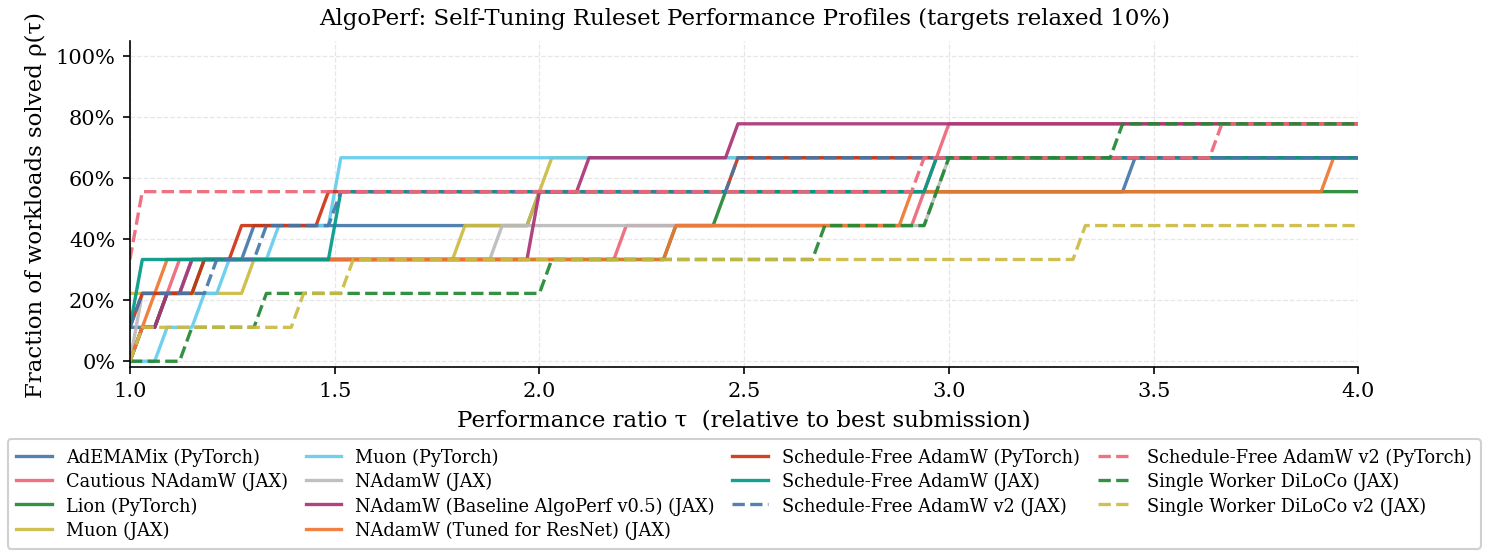


--- Leaderboard Scores (targets relaxed 10%) ---


,score
submission,
Schedule-Free AdamW v2 (PyTorch),0.607183
NAdamW (Baseline AlgoPerf v0.5) (JAX),0.601010
Muon (PyTorch),0.599327
Schedule-Free AdamW (PyTorch),0.578563
Schedule-Free AdamW v2 (JAX),0.574074
Schedule-Free AdamW (JAX),0.556117
Muon (JAX),0.552189
AdEMAMix (PyTorch),0.521324
Cautious NAdamW (JAX),0.508979


Saved to artifacts/tech_report_v1/section_4_leaderboards/out/byproducts/scores_relaxed.csv
\begin{table}[h]
  \centering
  \caption{AlgoPerf Self-Tuning Leaderboard (targets relaxed 10%)}
  \label{tab:scores_relaxed}
  \begin{tabular}{rlr}
    \toprule
    Rank & Submission & Score \\
    \midrule
    1 & \sfadamwii & \textbf{0.6072} \\
    2 & \nadamwbase & 0.6010 \\
    3 & \muonpt & 0.5993 \\
    4 & \sfadamw & 0.5786 \\
    5 & \sfadamwjaxii & 0.5741 \\
    6 & \sfadamwjax & 0.5561 \\
    7 & \muonjax & 0.5522 \\
    8 & \ademamix & 0.5213 \\
    9 & \cautiousnadamw & 0.5090 \\
    10 & \nadamw & 0.4815 \\
    11 & \lion & 0.4439 \\
    12 & \nadamwresnet & 0.4343 \\
    13 & \dilocosw & 0.4259 \\
    14 & \dilocoswii & 0.3232 \\
    \bottomrule
  \end{tabular}
\end{table}

Saved to artifacts/tech_report_v1/section_4_leaderboards/out/results/scores_relaxed_table.tex


In [71]:
TARGET_RELAXATION_FRACTION = 0.10  # 10% relaxation, applied to every workload

RELAXED_WORKLOAD_CONFIG = WORKLOAD_CONFIG.with_target_relaxations(
    {'all': TARGET_RELAXATION_FRACTION}
)

performance_profile_relaxed_df = performance_profile.compute_performance_profiles(
    results,
    RELAXED_WORKLOAD_CONFIG,
    time_col='score',
    min_tau=MIN_TAU,
    max_tau=MAX_TAU,
    reference_submission_tag=None,
    num_points=NUM_POINTS,
    scale=SCALE,
    verbosity=0,
    self_tuning_ruleset=SELF_TUNING_RULESET,
    strict=STRICT,
    output_dir=BYPRODUCTS_DIR,          # writes time_to_targets_relaxed.csv
    artifact_suffix='_relaxed',
)
performance_profile_relaxed_df.to_csv(
    os.path.join(BYPRODUCTS_DIR, 'performance_profile_score_relaxed.csv')
)

# ── Styled plot ────────────────────────────────────────────────────────────
fig, ax = plot_performance_profiles_styled(
    performance_profile_relaxed_df,
    'score_relaxed',
    scale=SCALE,
    save_dir=RESULTS_DIR,
    title=f'AlgoPerf: Self-Tuning Ruleset Performance Profiles '
          f'(targets relaxed {TARGET_RELAXATION_FRACTION:.0%})',
)
plt.show()

# ── Relaxed scores table ───────────────────────────────────────────────────
scores_relaxed = compute_leaderboard_score(performance_profile_relaxed_df)
scores_relaxed_path = os.path.join(BYPRODUCTS_DIR, 'scores_relaxed.csv')
scores_relaxed.to_csv(scores_relaxed_path)

print(f'\n--- Leaderboard Scores (targets relaxed {TARGET_RELAXATION_FRACTION:.0%}) ---')
display(scores_relaxed.sort_values('score', ascending=False))
print(f'Saved to {scores_relaxed_path}')

# ── LaTeX table ────────────────────────────────────────────────────────────
scores_relaxed_latex = scores_to_latex(
    scores_relaxed,
    caption=f'AlgoPerf Self-Tuning Leaderboard (targets relaxed {TARGET_RELAXATION_FRACTION:.0%})',
    label='tab:scores_relaxed',
)
print(scores_relaxed_latex)

scores_relaxed_latex_path = os.path.join(RESULTS_DIR, 'scores_relaxed_table.tex')
with open(scores_relaxed_latex_path, 'w') as f:
    f.write(scores_relaxed_latex)
print(f'\nSaved to {scores_relaxed_latex_path}')

In [72]:
# ── Time-to-Target Table (relaxed targets) ─────────────────────────────────
# Relaxed-target analog of Section 5b's time-to-target table: same _fmt()
# (fraction of the workload's time budget) and _WL_MACRO, against
# time_to_targets_relaxed.csv instead of the official time_to_targets.csv.
ttt_relaxed = pd.read_csv(
    os.path.join(BYPRODUCTS_DIR, 'time_to_targets_relaxed.csv'), index_col=0
)

ttt_relaxed_display = ttt_relaxed.apply(lambda col: col.map(lambda v: _fmt(col.name, v)))
ttt_relaxed_display.index.name = 'Submission'
# Order rows by relaxed leaderboard score (best first), matching this
# section's own leaderboard above.
ttt_relaxed_display = ttt_relaxed_display.loc[
    scores_relaxed.sort_values('score', ascending=False).index
]

print(f'--- Time to Target, targets relaxed {TARGET_RELAXATION_FRACTION:.0%} '
      f'(fraction of max runtime budget) ---')
display(ttt_relaxed_display)

_relaxed_workloads = list(ttt_relaxed.columns)
_relaxed_col_spec = 'l' + 'r' * len(_relaxed_workloads)
_relaxed_wl_headers = ' & '.join(_WL_MACRO.get(w, w) for w in _relaxed_workloads)

_relaxed_ttt_rows = []
for name, row in ttt_relaxed_display.iterrows():
    cells = [str(v).replace('%', r'\%') for v in row]
    _relaxed_ttt_rows.append('      ' + latex_name(name) + ' & ' + ' & '.join(cells) + r' \\')

_relaxed_budget_caption = (
    rf'Time to target with targets relaxed {TARGET_RELAXATION_FRACTION:.0%}, as a '
    r"fraction of each workload's self-tuning-ruleset time budget "
    rf'({SELF_TUNING_RUNTIME_FACTOR:g}\times the external-tuning maximum allowed runtime).'
    if SELF_TUNING_RULESET else
    rf'Time to target with targets relaxed {TARGET_RELAXATION_FRACTION:.0%}, as a '
    r"fraction of each workload's maximum allowed runtime."
)

ttt_relaxed_latex = '\n'.join([
    r'\begin{table}[htbp]',
    r'  \centering',
    r'  \caption{' + _relaxed_budget_caption + r' \textemdash{} = target not reached.}',
    r'  \label{tab:time_to_target_relaxed}',
    r'  \resizebox{\textwidth}{!}{%',
    r'  \begin{tabular}{' + _relaxed_col_spec + '}',
    r'    \toprule',
    r'    Submission & ' + _relaxed_wl_headers + r' \\',
    r'    \midrule',
    *_relaxed_ttt_rows,
    r'    \bottomrule',
    r'  \end{tabular}%',
    r'  }',
    r'\end{table}',
])

ttt_relaxed_latex_path = os.path.join(RESULTS_DIR, 'time_to_target_table_relaxed.tex')
with open(ttt_relaxed_latex_path, 'w') as f:
    f.write(ttt_relaxed_latex)
print(f'\nLaTeX saved → {ttt_relaxed_latex_path}')

--- Time to Target, targets relaxed 10% (fraction of max runtime budget) ---


,criteo1tb,fastmri,finewebedu_lm,imagenet_resnet,imagenet_vit,librispeech_conformer,librispeech_deepspeech,ogbg,wmt
submission,,,,,,,,,
Schedule-Free AdamW v2 (PyTorch),0.03,0.06,0.59,\textemdash{},\textemdash{},0.61,0.42,0.16,0.06
NAdamW (Baseline AlgoPerf v0.5) (JAX),0.03,0.07,0.32,0.43,0.56,\textemdash{},\textemdash{},0.13,0.11
Muon (PyTorch),0.03,0.08,0.22,\textemdash{},\textemdash{},0.72,\textemdash{},0.08,0.08
Schedule-Free AdamW (PyTorch),0.03,0.08,\textemdash{},\textemdash{},\textemdash{},0.72,0.42,0.13,0.08
Schedule-Free AdamW v2 (JAX),0.03,0.07,0.21,\textemdash{},0.27,\textemdash{},\textemdash{},0.13,0.08
Schedule-Free AdamW (JAX),0.03,0.09,0.16,\textemdash{},0.27,\textemdash{},\textemdash{},0.16,0.08
Muon (JAX),0.05,0.08,0.32,0.40,0.48,\textemdash{},\textemdash{},0.05,0.27
AdEMAMix (PyTorch),0.03,0.08,0.32,\textemdash{},\textemdash{},0.67,0.47,0.19,0.24
Cautious NAdamW (JAX),0.03,0.07,0.48,0.43,0.59,\textemdash{},\textemdash{},0.16,0.16



LaTeX saved → artifacts/tech_report_v1/section_4_leaderboards/out/results/time_to_target_table_relaxed.tex
